## Regresión Logística
La regresión logística es un algoritmo de clasificación, no de regresión, a pesar de su nombre. 
#
Su objetivo es predecir una clase (por ejemplo, 0 o 1, sí o no, aprobado o reprobado) en función de una o más variables independientes.
#
#
#
Se traduce a poder estimar la probabilidad de que una observación pertenezca a una clase. 




#### Resumen:

| Característica                  | Regresión Lineal             | Regresión Logística                 |
|--------------------------------|------------------------------|-------------------------------------|
| Tipo de problema               | Predicción de valores        | Clasificación binaria               |
| Salida                         | Número real                  | Probabilidad (entre 0 y 1)          |
| Función usada                  | Lineal                       | Función logística (sigmoide)        |
| Variables independientes (X)   | Numéricas y categóricas      | Numéricas y categóricas             |
| Variable dependiente (Y)       | Continua                     | Binaria (0 o 1)                     |
| Evaluación                     | RMSE, MAE, R²                | Accuracy, F1, AUC, Matriz de confusión |


### Ojo con el Umbral (Threshold)!
El algoritmo al final me devuelve una probabilidad entre 0 y 1.
#
El tema es que justamente tenemos que tener un **CRITERIO** que nos ayude a definir un **UMBRAL** que haga sentido. 
- ¿Qué pasa si estamos prediciendo si un paciente tiene cancer o no?
- ¿Qué pasa si estamos prediciendo la probabilidad de fraude?

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.linear_model import LogisticRegression
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

## Cargando el conjunto de datos

In [17]:
iris_raw = datasets.load_iris()

column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
iris = pd.DataFrame(iris_raw.data, columns=column_names)
iris['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)


iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Haciendo variables dummy de la especie

In [21]:
dummies = pd.get_dummies(iris['species'], dtype=int)
dummies.head()

,setosa,versicolor,virginica
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


## Uniendo las variables dummies al dataset original

In [22]:
datos = pd.concat([iris,dummies], axis=1) 
datos.head()

,sepal_length,sepal_width,petal_length,petal_width,species,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,setosa,1,0,0
1,4.9,3.0,1.4,0.2,setosa,1,0,0
2,4.7,3.2,1.3,0.2,setosa,1,0,0
3,4.6,3.1,1.5,0.2,setosa,1,0,0
4,5.0,3.6,1.4,0.2,setosa,1,0,0


In [23]:
versicolor = datos.pop("versicolor") 
virginica = datos.pop("virginica")
setosa = datos.pop("setosa")
datos.pop("species")

print(versicolor.head())
print(virginica.head())
print(setosa.head())
print(datos.head())

0    0
1    0
2    0
3    0
4    0
Name: versicolor, dtype: int64
0    0
1    0
2    0
3    0
4    0
Name: virginica, dtype: int64
0    1
1    1
2    1
3    1
4    1
Name: setosa, dtype: int64
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


Text(0.5, 1.0, 'Correlación de las variables numéricas de Iris')

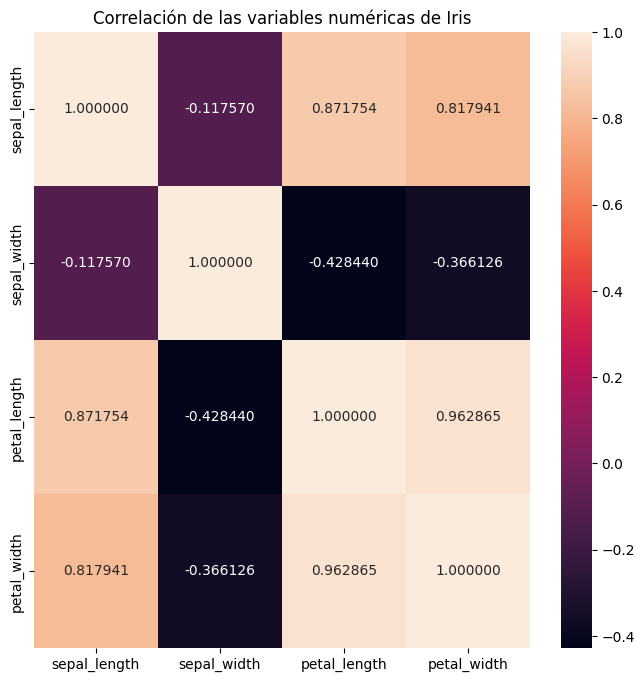

In [24]:
plt.subplots(figsize = (8,8))
sns.heatmap(datos.corr(),annot=True,fmt="f").set_title("Correlación de las variables numéricas de Iris")

### Separando en train y test

#### Virginica

In [25]:
y = virginica #La variable respuesta
X = datos #El resto de los datos
random.seed(123)

In [26]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7)

70% de entrenamiento y 30% prueba

In [27]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 124 to 77
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  105 non-null    float64
 1   sepal_width   105 non-null    float64
 2   petal_length  105 non-null    float64
 3   petal_width   105 non-null    float64
dtypes: float64(4)
memory usage: 4.1 KB


In [28]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 100 to 76
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  45 non-null     float64
 1   sepal_width   45 non-null     float64
 2   petal_length  45 non-null     float64
 3   petal_width   45 non-null     float64
dtypes: float64(4)
memory usage: 1.8 KB


### Creando el modelo

In [35]:
logReg = LogisticRegression(solver='liblinear')
logReg.fit(X_train,y_train)
y_pred = logReg.predict(X_test)
y_proba = logReg.predict_proba(X_test)[:,1] # vector de probabilidades
cm = confusion_matrix(y_test,y_pred)

In [36]:
y_proba

array([9.62012588e-01, 1.31891414e-01, 2.33771509e-05, 9.73303733e-05,
       8.50751774e-01, 7.11125072e-01, 3.44612831e-05, 4.90234487e-01,
       1.87240988e-04, 2.25131682e-01, 7.90344989e-01, 7.70062318e-01,
       5.84096125e-04, 5.99107836e-01, 5.63880908e-05, 5.25980207e-01,
       5.48765806e-01, 7.24281117e-01, 5.20731860e-05, 3.08918840e-01,
       1.36355425e-04, 8.99053688e-01, 1.26922670e-01, 7.92621787e-05,
       8.85295472e-01, 8.88326732e-02, 8.22550345e-01, 3.37314914e-05,
       9.29463590e-05, 8.52035234e-01, 8.26816689e-01, 9.30929152e-01,
       3.66011996e-05, 8.02504782e-01, 1.12765696e-04, 8.53951968e-01,
       2.42126796e-01, 1.30215177e-01, 1.17224846e-04, 2.39966834e-05,
       8.94536868e-01, 1.67112701e-04, 5.49010226e-05, 2.78154737e-01,
       2.01254466e-01])

In [37]:
y_test

100    1
69     0
22     0
6      0
142    1
149    1
5      0
68     0
24     0
54     0
115    1
146    1
41     0
141    1
49     0
138    1
127    1
137    1
39     0
55     0
43     0
113    1
58     0
2      0
144    1
57     0
106    1
4      0
9      0
135    1
120    1
105    1
28     0
111    1
47     0
109    1
89     0
92     0
42     0
48     0
143    1
3      0
20     0
87     0
76     0
Name: virginica, dtype: int64

In [38]:
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión para detectar virginica\n',cm)
print('Accuracy: ',accuracy)

Matriz de confusión para detectar virginica
 [[27  0]
 [ 0 18]]
Accuracy:  1.0


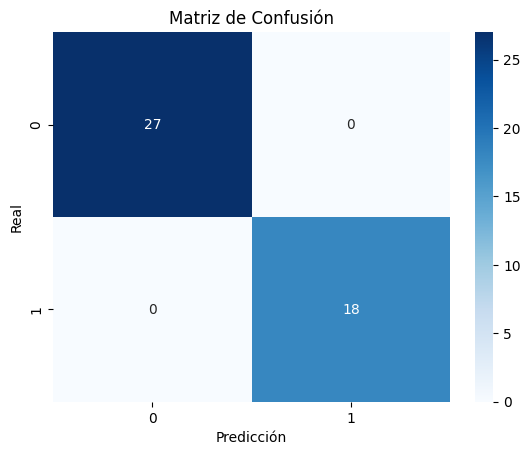

In [40]:
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

### Juguemos con el umbral

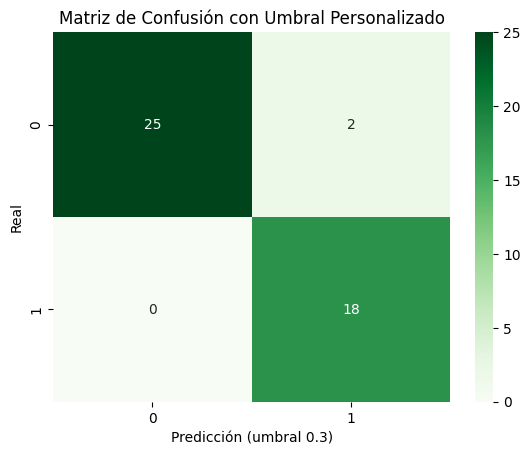

In [57]:
# Usar umbral distinto a 0.5
custom_threshold = 0.3
custom_preds = (y_proba >= custom_threshold).astype(int)

# Nueva matriz de confusión
cm_custom = confusion_matrix(y_test, custom_preds)
sns.heatmap(cm_custom, annot=True, cmap='Greens', fmt='d')
plt.xlabel("Predicción (umbral 0.3)")
plt.ylabel("Real")
plt.title("Matriz de Confusión con Umbral Personalizado")
plt.show()

#### AUROC vs RECALL

Área bajo la curva ROC (AUROC): 1.0


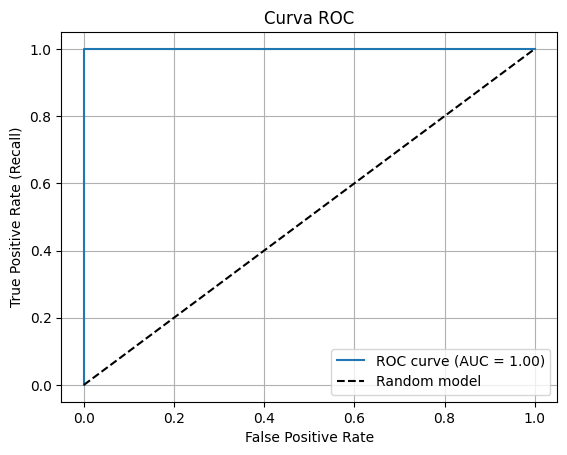

In [51]:
# Cálculo del AUROC
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

auroc = roc_auc_score(y_test, y_proba)
print("Área bajo la curva ROC (AUROC):", auroc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auroc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_df = pd.DataFrame({
    "Threshold": thresholds,
    "TPR (Recall)": tpr,
    "FPR": fpr
})

# Opcional: ajustar el formato para que sea más fácil de leer
pd.set_option('display.float_format', '{:.4f}'.format)

# Mostrar la tabla
print(roc_df)


   Threshold  TPR (Recall)    FPR
0        inf        0.0000 0.0000
1     0.9620        0.0556 0.0000
2     0.5260        1.0000 0.0000
3     0.0000        1.0000 1.0000


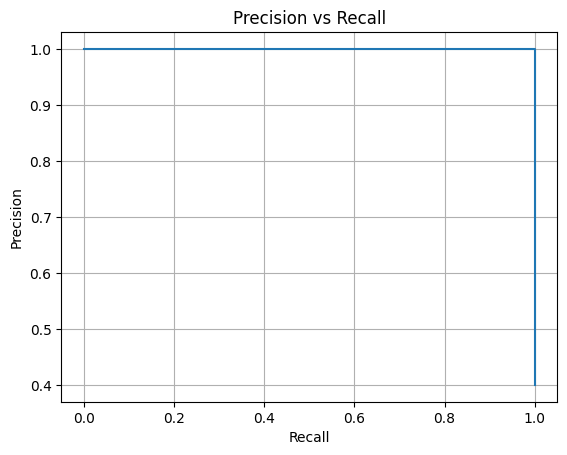

In [47]:
# RECALL
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(recall, precision, label="Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall")
plt.grid(True)
plt.show()


| Escenario                            | Métrica recomendada        |
|-------------------------------------|-----------------------------|
| Clases balanceadas                  | AUROC (Área bajo curva ROC) |
| Clases desbalanceadas               | Curva Precision-Recall      |
| Te interesa minimizar falsos negativos (FN) | Recall                    |
| Te interesa minimizar falsos positivos (FP) | Precision                 |
| Buscas una vista global del modelo  | AUROC                       |
